In [1]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
from scipy.optimize import fsolve
import numpy as np

In [2]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()
        state0 = torch.zeros(
            forces.shape[1:-1] + (self.discrete_equations.nstate,), device=forces.device
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[...,0:1]

In [4]:
nchunk = 50
nmodel = neml2.load_model("test_model_tensile.i", "implicit_rate")
nmodel.to(device = device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters = ["E_X", "E_Y", "elasticity_nu", "R_X", "d_X", "sy_X", "mu_X", "n_X"]), nchunk=nchunk)

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/ep [Scalar]
            old_state/mixed_state [SR2]
            state/internal/ep [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/ep [Scalar]
            residual/mixed_state [SR2]
Parameters: E_X [Scalar][Double][cuda:0]
            E_Y [Scalar][Double][cuda:0]
            R_X [Scalar][Double][cuda:0]
            R_Y [Scalar][Double][cuda:0]
            d_X [Scalar][Double][cuda:0]
            d_Y [Scalar][Double][cuda:0]
            elasticity_nu [Scalar][Double][cuda:0]
            mu_X [Scalar][Double][cuda:0]
            mu_Y [Scalar][Double][cuda:0]
            n_X [Scalar][Double][cuda:0]
            n_Y [Scalar][Double][cuda:0]
            sy_X [Scalar][Do

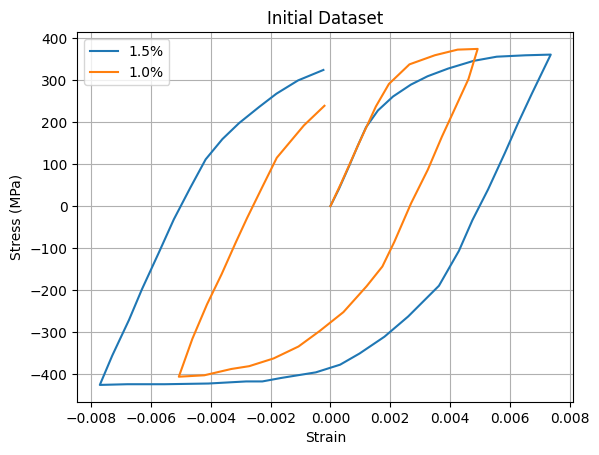

In [5]:
path = '/home/colinmoose/neml2/cmg_projects/cyclic_data'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if '1.5' in filename:
            sr_label = '1.5'
        elif '1.0' in filename:
            sr_label = '1.0'
        else:
            sr_label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{sr_label}_strain', 'y':f'{sr_label}_stress'})
        data_frames[sr_label] = new_df
strain_data = {}
stress_data = {}

for sr_label, df in data_frames.items():
    strain_col = f'{sr_label}_strain'
    stress_col = f'{sr_label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[sr_label] = strain
    stress_data[sr_label] = stress

# Plot initial dataset
plt.figure()
for sr_label in strain_data:
    plt.plot(strain_data[sr_label].cpu().numpy(), stress_data[sr_label].cpu().numpy(), label=f"{sr_label}%")
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Initial Dataset')
plt.grid()
plt.legend()
plt.show()


In [18]:
n_cycles = 10
points_per_cycle = 200   # controls sharpness of triangle wave peaks

ntemperature = 1
nrate = 1
ntime = n_cycles * points_per_cycle  # total time steps
nbatch = 2
rates = torch.tensor([3.0e-3], device=device)
temperatures = torch.tensor([550.0], device=device)
ranges = torch.tensor([0.01, 0.015], device=device)


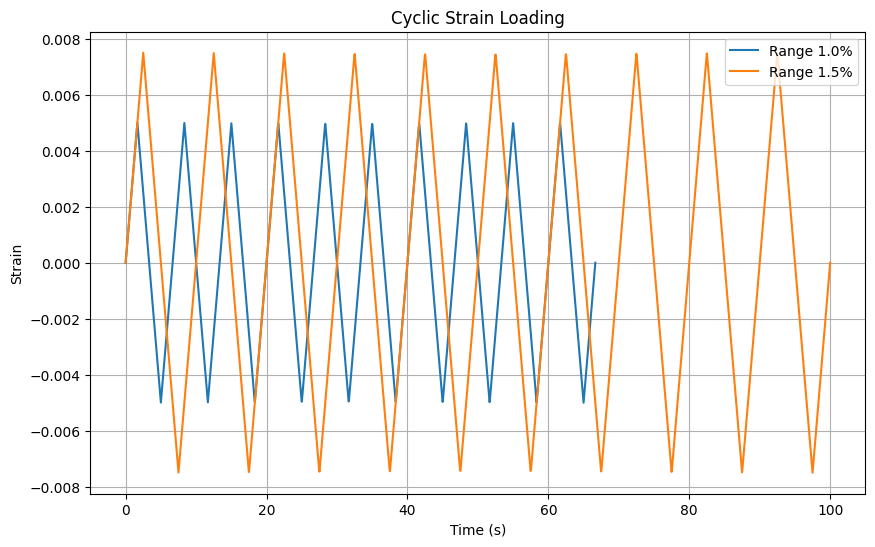


--- Full Input Tensors ---
time: torch.Size([2000, 2, 1])
temperature: torch.Size([2000, 2, 1])
loading: torch.Size([2000, 2, 6])


In [19]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

plt.figure(figsize=(10, 6))
for i, s_range in enumerate(ranges):
    amplitude = s_range.item() / 2.0
    period = 2.0 * s_range.item() / rates[0].item()
    total_time = n_cycles * period

    time_values = torch.linspace(0.0, total_time, ntime, device=device)

    strain_values = (2.0 * amplitude / torch.pi) * torch.arcsin(
        torch.sin(2.0 * torch.pi * time_values / period)
    )

    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    temperature[:, i, 0] = temperatures[0]

    plt.plot(time_values.cpu().numpy(), strain_values.cpu().numpy(),
             label=f"Range {s_range.item()*100:.1f}%")

plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Cyclic Strain Loading")
plt.legend()
plt.grid()
plt.show()

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


In [20]:
with torch.no_grad():
    stress = model(time, temperature, loading)

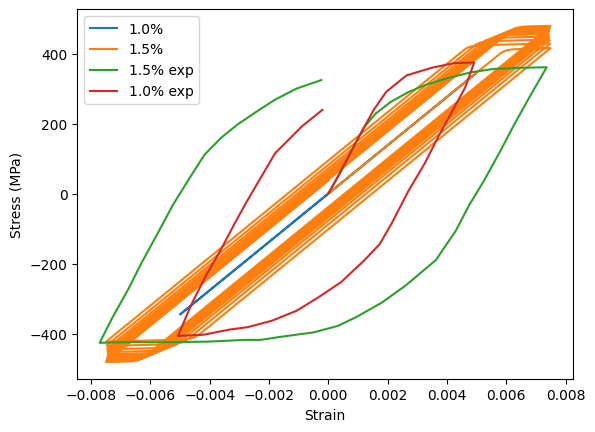

In [21]:
for i, s_range in enumerate(ranges):
    plt.plot(loading[:,i,0].cpu().numpy(), stress[:,i,0].cpu().numpy(), label=f'{s_range.item()*100}%')
for sr_label in strain_data:
    plt.plot(strain_data[sr_label].cpu().numpy(), stress_data[sr_label].cpu().numpy(), label=f"{sr_label}% exp")

plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.legend()
